In [4]:
from pathlib import Path
import math
import matplotlib.pyplot as plt


def generate_local_hopf_svg(
    output_path="local_hopf_oscillator.svg",
    size=512,
    stroke_color="#1f4fbf",
    stroke_width=4,
    spiral_color="#111111",
    label="",
):
    """
    Create a simple 'local Hopf oscillator' icon as SVG:
    - outer circle
    - inward spiral
    - small arrowhead on the spiral
    - optional label under the icon
    """
    size = int(size)
    cx = cy = size / 2
    outer_r = size * 0.36

    spiral_pts = []
    a = size * 0.02
    b = size * 0.11 / (2 * math.pi)
    t_start = 0.25 * math.pi
    t_end = 4.9 * math.pi
    n = 240

    for i in range(n):
        t = t_start + (t_end - t_start) * i / (n - 1)
        r = a + b * t
        x = cx + r * math.cos(t)
        y = cy + r * math.sin(t)
        spiral_pts.append((x, y))

    p1 = spiral_pts[-6]
    p2 = spiral_pts[-1]
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    norm = (dx**2 + dy**2) ** 0.5
    ux, uy = dx / norm, dy / norm
    px, py = -uy, ux

    arrow_len = size * 0.04
    arrow_w = size * 0.025

    tip = p2
    left = (
        p2[0] - arrow_len * ux + arrow_w * px,
        p2[1] - arrow_len * uy + arrow_w * py,
    )
    right = (
        p2[0] - arrow_len * ux - arrow_w * px,
        p2[1] - arrow_len * uy - arrow_w * py,
    )

    def fmt_pt(p):
        return f"{p[0]:.2f},{p[1]:.2f}"

    spiral_path = "M " + " L ".join(fmt_pt(p) for p in spiral_pts)
    arrow_points = " ".join(fmt_pt(p) for p in [tip, left, right])

    label_svg = ""
    if label:
        label_svg = (
            f'<text x="{cx:.2f}" y="{size*0.90:.2f}" '
            f'text-anchor="middle" '
            f'font-family="Arial, Helvetica, sans-serif" '
            f'font-size="{size*0.10:.1f}" '
            f'fill="#111111">{label}</text>'
        )

    svg = (
        f'<svg xmlns="http://www.w3.org/2000/svg" '
        f'width="{size}" height="{size}" viewBox="0 0 {size} {size}">\n'
        f'  <rect width="100%" height="100%" fill="white"/>\n'
        f'fill="none" stroke="{stroke_color}" stroke-width="{stroke_width}" '
        f'stroke-linecap="round" stroke-linejoin="round"/>\n'
        f'  <path d="{spiral_path}" '
        f'fill="none" stroke="{spiral_color}" stroke-width="{stroke_width*0.75}" '
        f'stroke-linecap="round" stroke-linejoin="round"/>\n'
        f'  <polygon points="{arrow_points}" fill="{spiral_color}"/>\n'
        f'  {label_svg}\n'
        f'</svg>\n'
    )

    Path(output_path).write_text(svg, encoding="utf-8")


In [5]:
generate_local_hopf_svg("local_hopf_oscillator.svg")


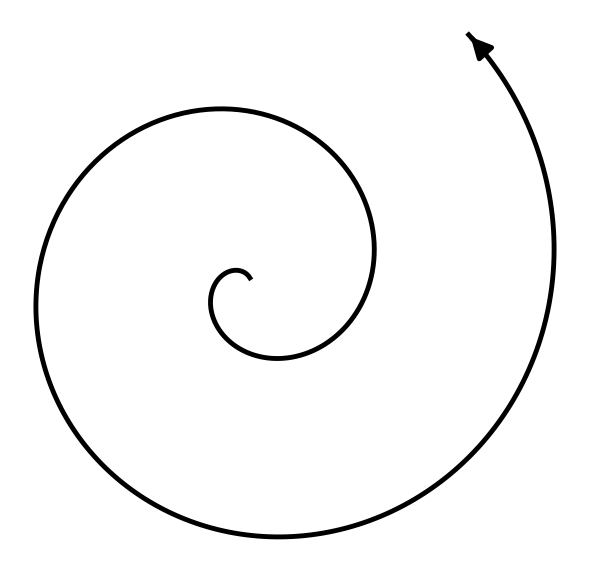

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Set up the figure
fig, ax = plt.subplots(figsize=(6, 6))

# 2. Generate the spiral data
# We use a parameter t (representing angle/time) to define the curve.
# Adjusting the max value of t controls how many loops the spiral makes.
t = np.linspace(0, 3.6 * np.pi, 500)

# Parametric equations for the spiral.
# We add a slight phase shift (np.pi/1.5) to match the orientation of your image.
x = t * np.cos(t + np.pi/1.5)
y = t * np.sin(t + np.pi/1.5)

# 3. Plot the main continuous curve
ax.plot(x, y, color='black', linewidth=3.5)

# 4. Add the arrowhead at the final point
# We use the last two data points to calculate the exact tangent direction for the arrow
ax.annotate('', 
            xy=(x[-1], y[-1]), 
            xytext=(x[-2], y[-2]),
            arrowprops=dict(arrowstyle="-|>", 
                            color='black', 
                            lw=3.5, 
                            mutation_scale=30)) # mutation_scale adjusts arrow size

# 5. Clean up the visual 
ax.set_aspect('equal') # Ensures the spiral doesn't get stretched into an oval
ax.axis('off')         # Hides the axes/grid lines for a clean look

# Display the result
plt.tight_layout()
plt.show()

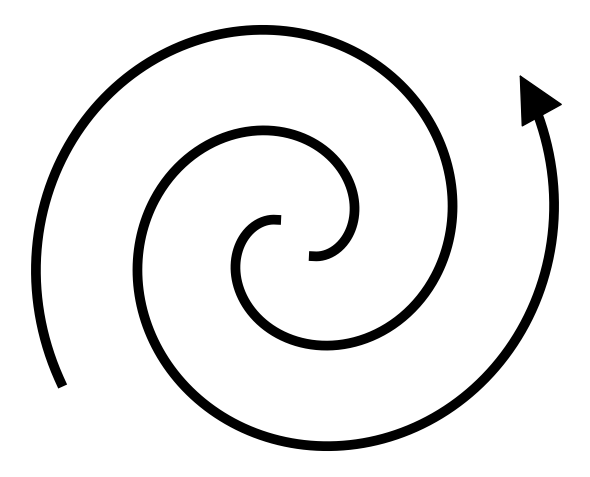

In [47]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

t = np.linspace(0.8, 2.7 * np.pi, 500)

scale = 0.2
phase = np.pi / 2
x1 = scale*t * np.cos(t + phase)
y1 = scale*t * np.sin(t + phase)
x2 = scale*t * np.cos(t + np.pi + phase)
y2 = scale*t * np.sin(t + np.pi + phase)

# Plot the lines stopping one point short of the end
# This prevents the flat line cap from poking through the arrow tip
ax.plot(x1[:-5], y1[:-5], color='black', linewidth=7)
ax.plot(x2[:-5], y2[:-5], color='black', linewidth=7)

# Add the arrows. shrinkA and shrinkB force zero padding.
# ax.annotate('', xy=(x1[-1], y1[-1]), xytext=(x1[-2], y1[-2]),
#             arrowprops=dict(arrowstyle="-|>", color='black', lw=3,
#                             mutation_scale=40, shrinkA=0, shrinkB=0))

# (If you only wanted ONE arrow on the whole graphic, delete this second block)
ax.annotate('', xy=(x2[-1], y2[-1]), xytext=(x2[-2], y2[-2]),
            arrowprops=dict(arrowstyle="-|>", color='black', mutation_scale=80, shrinkA=0, joinstyle='round', shrinkB=0))

ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()
plt.savefig("local_hopf_oscillator.svg", dpi=100, bbox_inches='tight', pad_inches=0)
plt.show()